# Default Parameters

In [1]:
filename = "bank-full.csv"
target_variable_name = "y"

# Load Dataset

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
df = spark.read.csv(filename, header=True, inferSchema=True, sep=';')
df.show()

+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

In [3]:
from pyspark.sql import functions as F

df = df.withColumn('label', F.when(F.col("y") == 'yes', 1).otherwise(0))
df = df.drop('y')

# Simple Random sampling

In [4]:
train, test = df.randomSplit([0.7, 0.3], seed=12345)

In [5]:
for k, v in df.dtypes:
    if v not in ['string']:
        print(k)

age
balance
day
duration
campaign
pdays
previous
label


In [6]:
df = df.select(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'label'])

In [7]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features']
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

In [8]:
#exclude target variable and select all other feature vectors
features_list = df.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove('label')

In [9]:
# apply the function on our dataframe
assembled_df = assemble_vectors(train, features_list, 'label')

In [10]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

lr = LogisticRegression(maxIter=10, featuresCol='features', labelCol='label')
paramGrid = ParamGridBuilder().addGrid(lr.regParam, [0.1, 0.01]).addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]).build()
train_valid_clf = TrainValidationSplit(estimator=lr, estimatorParamMaps=paramGrid, evaluator=BinaryClassificationEvaluator(),
                           # 70% of the data will be used for training, 30% for validation.
                           trainRatio=0.7)
model = train_valid_clf.fit(assembled_df)

# Stratified Sampling

In [11]:
# split data for 0s and 1s
zero_df = df.filter(df["label"]==0)
one_df = df.filter(df["label"]==1)

# split data into train and test
train_zero, test_zero = zero_df.randomSplit([0.7,0.3], seed=12345)
train_one, test_one = one_df.randomSplit([0.7,0.3], seed=12345)

# union datasets
train = train_zero.union(train_one)
test = test_zero.union(test_one)

# Holdout

In [12]:
train, test, holdout = df.randomSplit([0.7, 0.2, 0.1], seed=12345)

In [13]:
train.count(), test.count(), holdout.count()

(31559, 9024, 4628)

$$PSI=\sum (Actual \% - Expected\%) * ln( \frac{Actual\%}{Expected\%})$$

# k-fold cross validation

In [14]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

#model initialization
lr = LogisticRegression(maxIter=10, featuresCol='features', labelCol='label')

#model parameters to try
paramGrid = ParamGridBuilder().addGrid(lr.regParam, [0.1, 0.01]).addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]).build()

# number of folds = 3
crossval_clf = CrossValidator(estimator=lr, estimatorParamMaps=paramGrid, 
                                 evaluator=BinaryClassificationEvaluator(), numFolds=3, )

# assembled_df is the output of the vector assembler
model = crossval_clf.fit(assembled_df)

# Leave-one-group out cross validation

In [15]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import countDistinct
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F
import numpy as np

filename = "bank-full.csv"
spark = SparkSession.builder.getOrCreate()
df = spark.read.csv(filename, header=True, inferSchema=True, sep=';')
df = df.withColumn('label', F.when(F.col("y") == 'yes', 1).otherwise(0))
df = df.drop('y')
df = df.select(['education', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'label'])
features_list = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'] 

#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name, group_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [group_variable_name, target_variable_name, 'features']

    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

# apply the function on our dataframe
joined_df = assemble_vectors(df, features_list, 'label', 'education')
groups = list(joined_df.select('education').toPandas()['education'].unique())

# leave one group out validation 
def leave_one_group_out_validator(df, var_name, groups):
    
    train_metric_score = []
    test_metric_score = []
    
    for i in groups:
        train = df.filter(df[var_name]!=i)
        test = df.filter(df[var_name]==i)
    
        #model initialization
        lr = LogisticRegression(maxIter=10, featuresCol='features', labelCol='label')
        evaluator = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', 
                                                  metricName='areaUnderROC')
        #fit model
        lrModel = lr.fit(train)

        #make predicitons
        predict_train = lrModel.transform(train)
        predict_test = lrModel.transform(test)
        
        train_metric_score.append(evaluator.evaluate(predict_train))
        test_metric_score.append(evaluator.evaluate(predict_test))
        print(str(i) + " Group evaluation")
        print(" Train AUC - ", train_metric_score[-1])
        print(" Test AUC - ", test_metric_score[-1])
        
    print('Final evaluation for model')
    print('Train ROC', np.mean(train_metric_score))
    print('Test ROC', np.mean(test_metric_score))

In [16]:
leave_one_group_out_validator(joined_df, 'education', groups)

tertiary Group evaluation
 Train AUC -  0.8405077525701189
 Test AUC -  0.8116962363470843
secondary Group evaluation
 Train AUC -  0.8249661498139685
 Test AUC -  0.8352571672462351
unknown Group evaluation
 Train AUC -  0.8314694270462877
 Test AUC -  0.8111358354349012
primary Group evaluation
 Train AUC -  0.8256814343143658
 Test AUC -  0.8695878810485294
Final evaluation for model
Train ROC 0.8306561909361853
Test ROC 0.8319192800191875


# Regression models

In [17]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [18]:
from pyspark.sql.types import IntegerType
from pyspark.sql.types import StructField, StructType

cSchema = StructType([StructField("x1", IntegerType())\
                      ,StructField("x2", IntegerType())\
                      ,StructField("y", IntegerType())])

df_list = [[58, 50, 12], [37, 95, 27], [29, 137, 39], [19, 150, 45]]


df = spark.createDataFrame(df_list, schema=cSchema)
df.show()

+---+---+---+
| x1| x2|  y|
+---+---+---+
| 58| 50| 12|
| 37| 95| 27|
| 29|137| 39|
| 19|150| 45|
+---+---+---+



In [23]:
assembled_df = assemble_vectors(df, ['x1'], 'y')

In [24]:
from pyspark.ml.regression import LinearRegression

reg = LinearRegression(featuresCol='features', labelCol='y')

In [25]:
reg_model = reg.fit(assembled_df)

In [26]:
print(reg_model.coefficients[0], reg_model.intercept)

-0.8705560619872369 61.87237921604372


In [27]:
pred_result = reg_model.transform(assembled_df)

In [28]:
reg_summary = reg_model.summary

print('Mean Squared error', reg_summary.meanSquaredError)
print('Root mean squared error', reg_summary.rootMeanSquaredError)
print('Mean Absolute error', reg_summary.meanAbsoluteError)
print('Explained Variance', reg_summary.explainedVariance)
print('R squared', reg_summary.r2)

Mean Squared error 3.303555150410206
Root mean squared error 1.8175684720004928
Mean Absolute error 1.496809480401085
Explained Variance 155.8839448495894
R squared 0.9792473959927117


# Mean square error

In [29]:
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(labelCol='y', predictionCol='prediction', metricName='mse')

In [30]:
evaluator.evaluate(pred_result)

3.303555150410206

# Root Mean Square error

In [31]:
evaluator = RegressionEvaluator(labelCol='y', predictionCol='prediction', metricName='rmse')
evaluator.evaluate(pred_result)

1.8175684720004928

# Mean absolute error

In [32]:
evaluator = RegressionEvaluator(labelCol='y', predictionCol='prediction', metricName='mae')
evaluator.evaluate(pred_result)

1.496809480401085

# Explained Variance

In [33]:
# option available for Pyspark 3.0 and above
evaluator = RegressionEvaluator(labelCol='y', predictionCol='prediction', metricName='var')
evaluator.evaluate(pred_result)

155.8839448495894

In [34]:
# PySpark < 3.0
print('Explained Variance', reg_summary.explainedVariance)

Explained Variance 155.8839448495894


In [35]:
1 - 4

-3

# R- Squared

In [36]:
1 - (3.303/159.19)

0.979251209246812

In [37]:
evaluator = RegressionEvaluator(labelCol='y', predictionCol='prediction', metricName='r2')
evaluator.evaluate(pred_result)
print('R squared', reg_summary.r2)

R squared 0.9792473959927117


# Adjusted R squared

In [38]:
print('R squared', reg_summary.r2adj)

R squared 0.9688710939890676


In [39]:
1 - (((1-0.97924)*3)/(4-1-1))

0.96886

In [40]:
(12 + 27 + 39 + 45)/4

30.75

# Binary Classification

In [41]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features']
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

In [42]:
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.sql.types import StructField, StructType

cSchema = StructType([StructField("x1", IntegerType())\
                      ,StructField("x2", IntegerType())\
                      ,StructField("target", IntegerType())])

df_list = [[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]]


df = spark.createDataFrame(df_list, schema=cSchema)
df.show()

assembled_df = assemble_vectors(df, ['x1'], 'target')

from pyspark.ml.classification import LogisticRegression

clf = LogisticRegression(featuresCol='features', labelCol='target')

clf_model = clf.fit(assembled_df)

print(clf_model.coefficients[0], clf_model.intercept)

pred_result = clf_model.transform(assembled_df)

+---+---+------+
| x1| x2|target|
+---+---+------+
|  0|  0|     0|
|  0|  1|     1|
|  1|  0|     1|
|  1|  1|     1|
+---+---+------+

14.49962091530358 -7.577805938296933e-09


In [43]:
pred_result.show()

+------+--------+--------------------+--------------------+----------+
|target|features|       rawPrediction|         probability|prediction|
+------+--------+--------------------+--------------------+----------+
|     0|   [0.0]|[7.57780593829693...|[0.50000000189445...|       0.0|
|     1|   [0.0]|[7.57780593829693...|[0.50000000189445...|       0.0|
|     1|   [1.0]|[-14.499620907725...|[5.04538638555646...|       1.0|
|     1|   [1.0]|[-14.499620907725...|[5.04538638555646...|       1.0|
+------+--------+--------------------+--------------------+----------+



In [44]:
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics

predictionAndTarget = pred_result.select("prediction", "target")
predictionAndTarget = predictionAndTarget.withColumn("target", predictionAndTarget["target"].cast(DoubleType()))
predictionAndTarget = predictionAndTarget.withColumn("prediction", predictionAndTarget["prediction"].cast(DoubleType()))

metrics = MulticlassMetrics(predictionAndTarget.rdd.map(tuple))

/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [45]:
# confusion matrix
cm = metrics.confusionMatrix().toArray()

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

def make_confusion_matrix_chart(cf_matrix):
    
    list_values = ['0', '1']

    plt.subplot(111)
    sns.heatmap(cf_matrix, annot=True, yticklabels=list_values, 
                                xticklabels=list_values, fmt='g')
    plt.ylabel("Actual")
    plt.xlabel("Pred")
    plt.ylim([0,2])
    plt.title('OR Logic Gate predictions')

    plt.tight_layout()
    return None

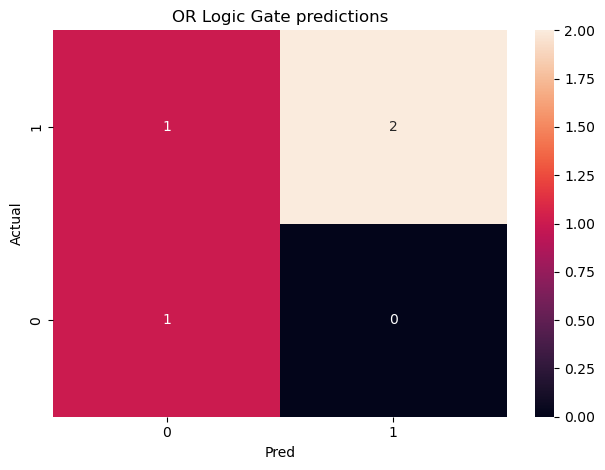

In [47]:
make_confusion_matrix_chart(cm)

$$Sigmoid\ function,\ Probability=(\frac{1}{1 + exp(-x)})$$

$$Accuracy=(\frac{TP + TN}{TP + TN + FP + FN})$$

$$Precision=(\frac{TP}{TP + FP})$$

$$Recall=(\frac{TP}{TP + FN})$$

$$F1-score=2*(\frac{Precision*Recall}{Precision + Recall})$$

$$Specificity=(\frac{TN}{TN + FP})=1- FPR$$

$$False\ Positive\ Rate=(\frac{FP}{FP + TN})$$

In [48]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
acc = metrics.accuracy
misclassification_rate = 1 - acc
precision = metrics.precision(1.0)
recall = metrics.recall(1.0)
f1 = metrics.fMeasure(1.0)
evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderROC')
roc = evaluator.evaluate(pred_result)

In [49]:
print(acc, misclassification_rate, precision, recall, f1, roc)

0.75 0.25 1.0 0.6666666666666666 0.8 0.8333333333333333


In [50]:
from pyspark.mllib.evaluation import BinaryClassificationMetrics

class CurveMetrics(BinaryClassificationMetrics):
    def __init__(self, *args):
        super(CurveMetrics, self).__init__(*args)

    def _to_list(self, rdd):
        points = []
        results_collect = rdd.collect()
        for row in results_collect:
            points += [(float(row._1()), float(row._2()))]
        return points

    def get_curve(self, method):
        rdd = getattr(self._java_model, method)().toJavaRDD()
        return self._to_list(rdd)

In [51]:
preds = pred_result.select('target','probability').rdd.map(lambda row: (float(row['probability'][1]), float(row['target'])))

# Returns as a list (false positive rate, true positive rate)
points = CurveMetrics(preds).get_curve('roc')

/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


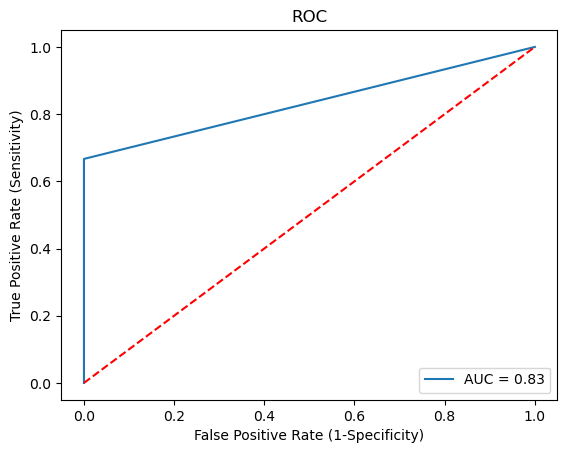

In [52]:
import matplotlib.pyplot as plt
points = CurveMetrics(preds).get_curve('roc')

plt.figure()
x_val = [x[0] for x in points]
y_val = [x[1] for x in points]
plt.title('ROC')
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.plot(x_val, y_val, label = 'AUC = %0.2f' % roc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.legend(loc = 'lower right')

In [53]:
evaluator = BinaryClassificationEvaluator(labelCol='target', rawPredictionCol='rawPrediction', metricName='areaUnderPR')
pr = evaluator.evaluate(pred_result)

In [54]:
pr

0.9583333333333333

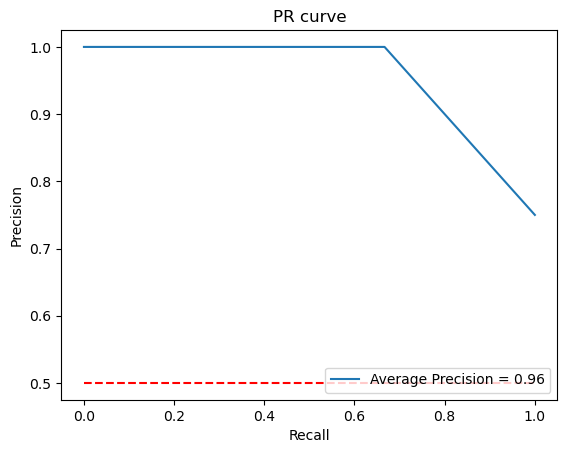

In [55]:
preds = pred_result.select('target','probability').rdd.map(lambda row: (float(row['probability'][1]), float(row['target'])))
points = CurveMetrics(preds).get_curve('pr')

plt.figure()
x_val = [x[0] for x in points]
y_val = [x[1] for x in points]
plt.title('PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(x_val, y_val, label = 'Average Precision = %0.2f' % pr)
plt.plot([0, 1], [0.5, 0.5], color='red', linestyle='--')
plt.legend(loc = 'lower right')

# Random Value

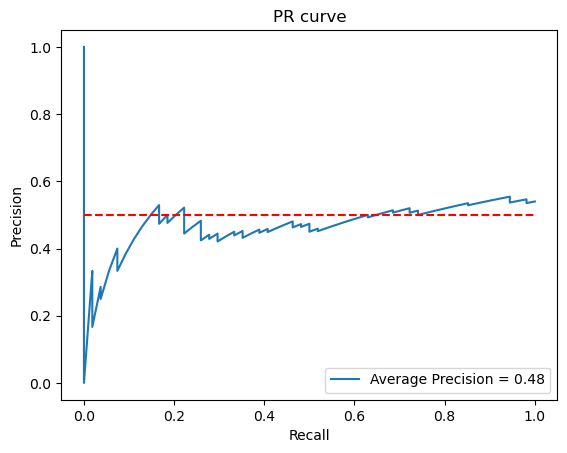

In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import random

# random target and probabilities
rand_y = [random.choice([1, 0]) for i in range(0, 100)]
rand_prob = [random.uniform(0, 1) for i in range(0, 100)]
rand_precision, rand_recall, _ = precision_recall_curve(rand_y, rand_prob)
pr = average_precision_score(rand_y, rand_prob)
#plot random predictions
plt.figure()
plt.title('PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.plot(rand_recall, rand_precision, label = 'Average Precision = %0.2f' % pr)
plt.plot([0, 1], [0.5, 0.5], color='red', linestyle='--')
plt.legend(loc = 'lower right')

# KS Statistic

In [65]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import countDistinct
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F
import numpy as np

filename = "bank-full.csv"
spark = SparkSession.builder.getOrCreate()
df = spark.read.csv(filename, header=True, inferSchema=True, sep=';')
df = df.withColumn('label', F.when(F.col("y") == 'yes', 1).otherwise(0))
df = df.drop('y')
#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features']
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

df = df.select(['education', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'label'])
features_list = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'] 
assembled_df = assemble_vectors(df, features_list, 'label')
clf = LogisticRegression(featuresCol='features', labelCol='label')
train, test = assembled_df.randomSplit([0.7, 0.3], seed=12345)
clf_model = clf.fit(train)

In [66]:
from pyspark.sql import Window

def create_deciles(df, clf, score, prediction, target, buckets):
    
    # get predictions from model
    pred = clf.transform(df)
    #probability of 1's, prediction and target
    pred = pred.select(F.col(score), F.col(prediction), F.col(target)).rdd.map(lambda row: (float(row[score][1]), float(row['prediction']), float(row[target])))
    predDF = pred.toDF(schema=[score, prediction, target])
    # remove ties in scores work around
    window = Window.orderBy(F.desc(score))
    predDF = predDF.withColumn("row_number", F.row_number().over(window))
    predDF.cache()
    predDF = predDF.withColumn("row_number", predDF['row_number'].cast("double"))
    # partition into 10 buckets
    window2 = Window.orderBy("row_number")
    final_predDF = predDF.withColumn("deciles", F.ntile(buckets).over(window2))
    final_predDF = final_predDF.withColumn("deciles", final_predDF['deciles'].cast("int"))
    # create non target column
    final_predDF = final_predDF.withColumn("non_target", 1 - final_predDF[target])
    final_predDF.cache()    #final predicted df
    
    #ks calculation starts here
    temp_deciles = final_predDF.groupby('deciles').agg(F.sum(target).alias(target)).toPandas()
    non_target_cnt = final_predDF.groupby('deciles').agg(F.sum('non_target').alias('non_target')).toPandas()
    temp_deciles = temp_deciles.merge(non_target_cnt, on='deciles', how='inner')
    temp_deciles = temp_deciles.sort_values(by='deciles', ascending=True)
    temp_deciles['total'] = temp_deciles[target] + temp_deciles['non_target']
    temp_deciles['target_%'] = (temp_deciles[target] / temp_deciles['total'])*100
    temp_deciles['cum_target'] = temp_deciles[target].cumsum()
    temp_deciles['cum_non_target'] = temp_deciles['non_target'].cumsum()
    temp_deciles['target_dist'] = (temp_deciles['cum_target']/temp_deciles[target].sum())*100
    temp_deciles['non_target_dist'] = (temp_deciles['cum_non_target']/temp_deciles['non_target'].sum())*100
    temp_deciles['spread'] = temp_deciles['target_dist'] - temp_deciles['non_target_dist']
    decile_table=temp_deciles.round(2)
    decile_table = decile_table[['deciles', 'total', 'label', 'non_target', 'target_%', 'cum_target', 'cum_non_target', 'target_dist', 'non_target_dist', 'spread']]
    print("KS Value - ", round(temp_deciles['spread'].max(), 2))
    return final_predDF, decile_table

In [67]:
pred_train, train_deciles = create_deciles(train, clf_model, 'probability', 'prediction', 'label', 10)
pred_test, test_deciles = create_deciles(test, clf_model, 'probability', 'prediction', 'label', 10)

KS Value -  49.84
KS Value -  49.38


In [99]:
from collections import OrderedDict
import pandas as pd
import sys
%matplotlib inline
    
def plot_pandas_style(styler):
    from IPython.core.display import HTML
    style = styler.format(precision=2).background_gradient(cmap='RdYlGn')
    return HTML(style.to_html())

def highlight_max(s,color='yellow'):
    '''
    highlight the maximum in a Series yellow.
    '''
    is_max = s == s.max()
    return ['background-color: {}'.format(color) if v else '' for v in is_max]

def decile_labels(agg1, target, color='skyblue'):
    agg1 = agg1.round(2)
    agg1 = agg1.style.apply(highlight_max, color = 'yellow', subset=['spread']).format("{:.2f}")
    agg1.bar(subset=[target], color='{}'.format(color), vmin=0)
    agg1.bar(subset=['total'], color='{}'.format(color), vmin=0)
    agg1.bar(subset=['target_%'], color='{}'.format(color), vmin=0)
    return agg1


In [100]:
plot_decile_test = decile_labels(test_deciles, 'label', color='skyblue')
plot_pandas_style(plot_decile_test)

,deciles,total,label,non_target,target_%,cum_target,cum_non_target,target_dist,non_target_dist,spread
0,1,1366.00,612.00,754.00,44.80,612.00,754.00,40.50,6.21,34.29
1,2,1366.00,292.00,1074.00,21.38,904.00,1828.00,59.83,15.06,44.77
2,3,1365.00,213.00,1152.00,15.60,1117.00,2980.00,73.92,24.54,49.38
3,4,1365.00,150.00,1215.00,10.99,1267.00,4195.00,83.85,34.55,49.30
4,5,1365.00,104.00,1261.00,7.62,1371.00,5456.00,90.73,44.94,45.80
5,6,1365.00,59.00,1306.00,4.32,1430.00,6762.00,94.64,55.70,38.94
6,7,1365.00,38.00,1327.00,2.78,1468.00,8089.00,97.15,66.63,30.53
7,8,1365.00,24.00,1341.00,1.76,1492.00,9430.00,98.74,77.67,21.07
8,9,1365.00,16.00,1349.00,1.17,1508.00,10779.00,99.80,88.78,11.02
9,10,1365.00,3.00,1362.00,0.22,1511.00,12141.00,100.00,100.00,0.00


# Actual vs Predicted, Gains and Lift chart

In [101]:
import matplotlib.pyplot as plt

def plots(agg1,target,type):

    plt.figure(1,figsize=(20, 5))

    plt.subplot(131)
    plt.plot(agg1['DECILE'],agg1['ACTUAL'],label='Actual')
    plt.plot(agg1['DECILE'],agg1['PRED'],label='Pred')
    plt.xticks(range(10,110,10))
    plt.legend(fontsize=15)
    plt.grid(True)
    plt.title('Actual vs Predicted', fontsize=20)
    plt.xlabel("Population %",fontsize=15)
    plt.ylabel(str(target) + " " + str(type) + " %",fontsize=15)

    plt.subplot(132)
    X = agg1['DECILE'].tolist()
    X.append(0)
    Y = agg1['DIST_TAR'].tolist()
    Y.append(0)
    plt.plot(sorted(X),sorted(Y))
    plt.plot([0, 100], [0, 100],'r--')
    plt.xticks(range(0,110,10))
    plt.yticks(range(0,110,10))
    plt.grid(True)
    plt.title('Gains Chart', fontsize=20)
    plt.xlabel("Population %",fontsize=15)
    plt.ylabel(str(target) + str(" DISTRIBUTION") + " %",fontsize=15)
    plt.annotate(round(agg1[agg1['DECILE'] == 30].DIST_TAR.item(),2),xy=[30,30], 
            xytext=(25, agg1[agg1['DECILE'] == 30].DIST_TAR.item() + 5),fontsize = 13)
    plt.annotate(round(agg1[agg1['DECILE'] == 50].DIST_TAR.item(),2),xy=[50,50], 
            xytext=(45, agg1[agg1['DECILE'] == 50].DIST_TAR.item() + 5),fontsize = 13)

    plt.subplot(133)
    plt.plot(agg1['DECILE'],agg1['LIFT'])
    plt.xticks(range(10,110,10))
    plt.grid(True)
    plt.title('Lift Chart', fontsize=20)
    plt.xlabel("Population %",fontsize=15)
    plt.ylabel("Lift",fontsize=15)

    plt.tight_layout()

In [102]:
def gains(data, decile_df, decile_by, target, score):
    
    agg1 = pd.DataFrame({},index=[])
    agg1 = data.groupby(decile_by).agg(F.avg(target).alias('ACTUAL')).toPandas()
    score_agg = data.groupby(decile_by).agg(F.avg(score).alias('PRED')).toPandas()
    agg1 = agg1.merge(score_agg, on=decile_by, how='inner').merge(decile_df, on=decile_by, how='inner')    
    agg1 = agg1.sort_values(by=decile_by, ascending=True)
    agg1 = agg1[[decile_by, 'ACTUAL', 'PRED', 'target_dist']]
    agg1 = agg1.rename(columns={'target_dist':'DIST_TAR', 'deciles': 'DECILE'})
    decile_by = 'DECILE'
    agg1[decile_by] = agg1[decile_by]*10
    agg1['LIFT'] = agg1['DIST_TAR']/agg1[decile_by]
    agg1.columns = [x.upper() for x in agg1.columns]
    plots(agg1,target,'Distribution')

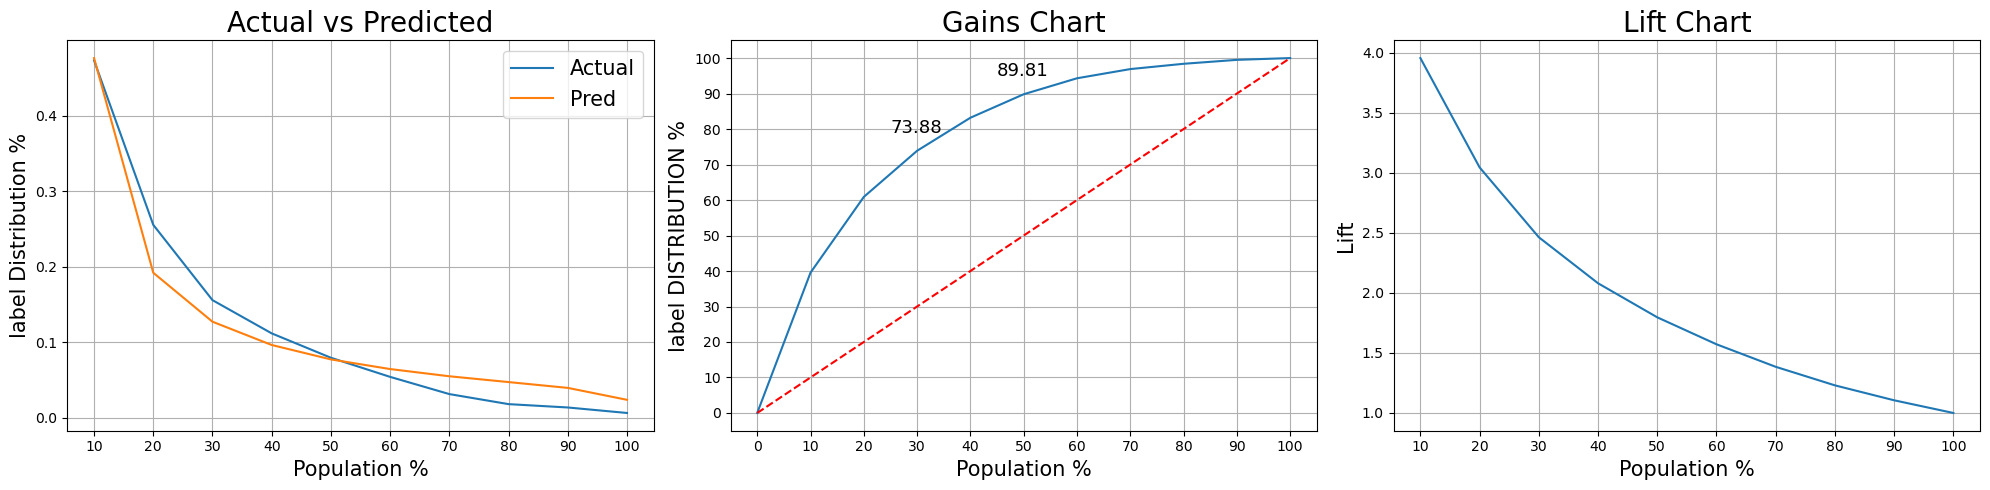

In [103]:
gains(pred_train, train_deciles, 'deciles', 'label','probability')

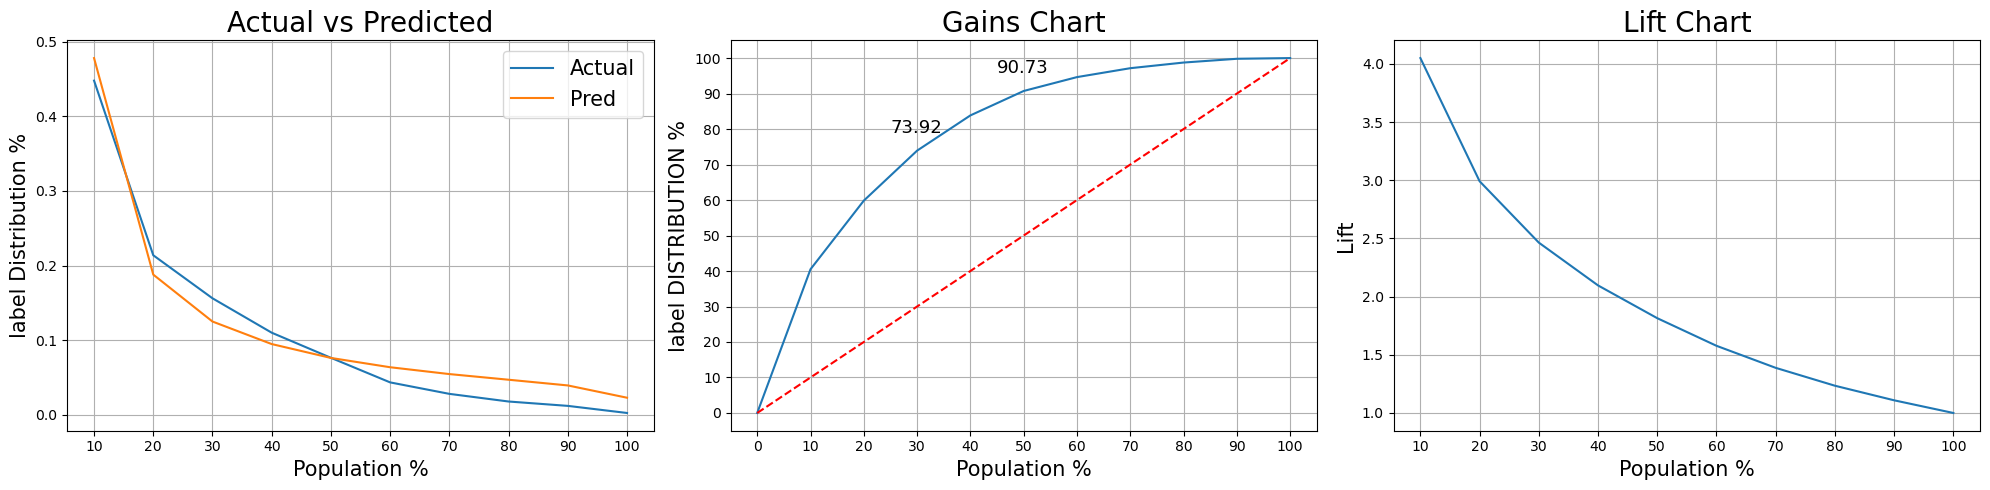

In [104]:
gains(pred_test, test_deciles, 'deciles', 'label','probability')